In [5]:
import joblib
import os

# --- PASO DE SEGURIDAD: Crear la carpeta si no existe ---
if not os.path.exists('../models'):
    os.makedirs('../models')
    print("📂 Carpeta '../models' creada exitosamente.")

# 1. Guardar el modelo
print("💾 Guardando el modelo entrenado...")
joblib.dump(model, '../models/xgb_fraud_detector.joblib')

# 2. Guardar nombres de columnas
model_columns = list(X_train.columns)
joblib.dump(model_columns, '../models/model_columns.joblib')

print(f"✅ ¡Todo listo! Modelo guardado en /models/xgb_fraud_detector.joblib")

📂 Carpeta '../models' creada exitosamente.
💾 Guardando el modelo entrenado...
✅ ¡Todo listo! Modelo guardado en /models/xgb_fraud_detector.joblib


🧠 Iniciando análisis de explicabilidad con SHAP...


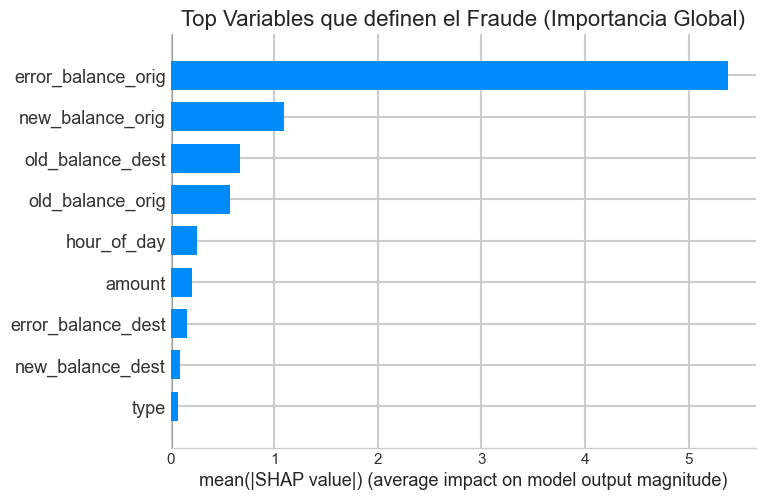

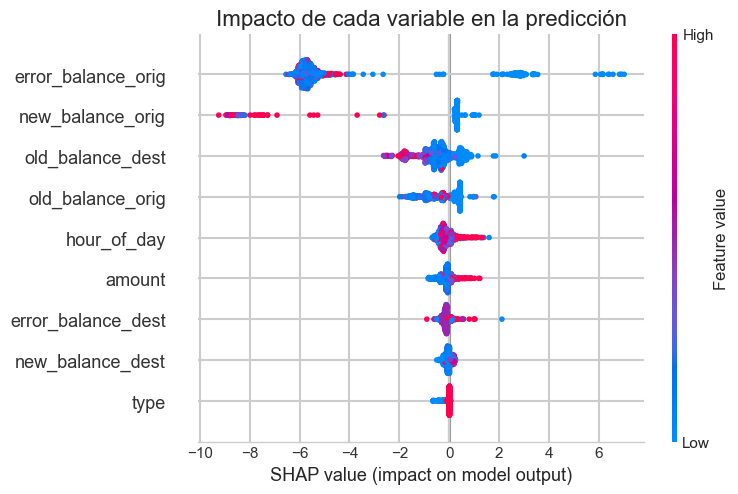

In [3]:
import shap

# 1. Preparar el Explicador (TreeExplainer es optimizado para XGBoost)
print("🧠 Iniciando análisis de explicabilidad con SHAP...")
explainer = shap.TreeExplainer(model)

# 2. Calcular valores SHAP
# IMPORTANTE: Usamos solo una muestra (1000 filas) porque calcularlo para todo el dataset tardaría horas.
# Tomamos una muestra aleatoria del set de prueba.
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 3. Visualizar: Summary Plot
# Esta es la gráfica MÁS IMPORTANTE en Ciencia de Datos para Negocios.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title('Top Variables que definen el Fraude (Importancia Global)', fontsize=16)
plt.show()

# 4. Visualizar: Beehive Plot (Para ver la dirección del impacto)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('Impacto de cada variable en la predicción', fontsize=16)
plt.show()

In [2]:
# 5. DEFINICIÓN DEL MODELO
# scale_pos_weight: Ayuda con el desbalanceo. 
# Una fórmula empírica es: sum(negativos) / sum(positivos)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"⚖️ Ratio de desbalanceo calculado: {ratio:.2f}")

model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=ratio,  # ¡Clave para fraude!
    n_estimators=100,        # Número de árboles
    learning_rate=0.1,
    max_depth=4,
    n_jobs=-1,               # Usar todos los núcleos del CPU
    random_state=42
)

# 6. ENTRENAMIENTO
print("\n🤖 Entrenando modelo XGBoost (esto puede tardar 1-2 mins)...")
model.fit(X_train, y_train)
print("✅ Entrenamiento finalizado.")

# 7. EVALUACIÓN INICIAL
# Predecimos probabilidades, no solo 0 o 1
y_pred_prob = model.predict_proba(X_test)[:, 1]

auc_roc = roc_auc_score(y_test, y_pred_prob)
auc_pr = average_precision_score(y_test, y_pred_prob)

print("\n📊 RESULTADOS PRELIMINARES:")
print(f"AUC-ROC: {auc_roc:.4f} (Capacidad de distinción global)")
print(f"AUC-PR:  {auc_pr:.4f}  (¡La métrica reina en desbalanceo!)")

⚖️ Ratio de desbalanceo calculado: 559.67

🤖 Entrenando modelo XGBoost (esto puede tardar 1-2 mins)...
✅ Entrenamiento finalizado.

📊 RESULTADOS PRELIMINARES:
AUC-ROC: 1.0000 (Capacidad de distinción global)
AUC-PR:  0.9976  (¡La métrica reina en desbalanceo!)


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual estilo "Paper"
sns.set_context("talk")
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Cargar el dataset optimizado
print("⏳ Cargando datos procesados...")
df = pd.read_parquet('../data/processed/transactions_clean.parquet')

# 2. FILTRADO ESTRATÉGICO (Conocimiento de Dominio)
# El fraude solo existe en TRANSFER y CASH_OUT en este dataset.
# Filtrar reduce ruido y memoria.
print(f"Dimensiones originales: {df.shape}")
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
print(f"Dimensiones tras filtrado de riesgo: {df.shape}")

# 3. PREPROCESAMIENTO RÁPIDO
# Convertir 'type' a números (Label Encoding)
df['type'] = df['type'].map({'TRANSFER': 0, 'CASH_OUT': 1})

# Eliminar columnas que no usaremos aun (Nombres y Strings)
# Nota: 'is_flagged_fraud' es una regla tonta del sistema viejo, la quitamos para que el modelo aprenda solo.
X = df.drop(['is_fraud', 'name_orig', 'name_dest', 'is_flagged_fraud', 'step'], axis=1)
y = df['is_fraud']

# 4. TIME-BASED SPLIT (¡Crucial para Banca!)
# No usamos random_split. Cortamos por tiempo.
split_idx = int(len(X) * 0.8) # 80% para entrenar, 20% para testear

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\n✅ Split Temporal Realizado:")
print(f"Train set: {X_train.shape[0]:,} transacciones (Pasado)")
print(f"Test set:  {X_test.shape[0]:,} transacciones (Futuro)")

⏳ Cargando datos procesados...
Dimensiones originales: (6362620, 14)
Dimensiones tras filtrado de riesgo: (2770409, 14)

✅ Split Temporal Realizado:
Train set: 2,216,327 transacciones (Pasado)
Test set:  554,082 transacciones (Futuro)
